## **Image Data Enrichment - Open CV for CIFAR-10**

The objective of this Python notebook is to compare 6 different image data enrichment techniques on the CIFAR-10 dataset, via OpenCV.

The methods used here are:

- No Processing
- Rotation
- Translation
- Scaling
- Noise
- Blur


### **Data Preparation**

This data below is to import the CIFAR-10 dataset after the cleaning operation of Standard Scaling via open CV, which has the best image cleaning effect after comparison.

In [ ]:
import numpy as np
import cv2
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense
from keras.optimizers import Adam

# CIFAR-10: 32×32×3
(trainImg, trainLabel), (testImg, testLabel) = cifar10.load_data()

# one-hot label
trainLabelCategorical = to_categorical(trainLabel, 10)
testLabelCategorical = to_categorical(testLabel, 10)

In [ ]:
# StandardScaler

def standardScaling(img):
  img = img.astype(np.float32)
  mean = np.mean(img)
  std = np.std(img)

  return (img - mean) / std

### **Image Data Enrichment Methods**

In [5]:
def NoProcessing(img):
    return img

In [6]:
def Rotation(img, angle=15):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), np.random.uniform(-angle, angle), 1)
    return cv2.warpAffine(img, M, (w, h))

In [7]:
def Translation(img, shift=4):
    M = np.float32([
        [1, 0, np.random.randint(-shift, shift)],
        [0, 1, np.random.randint(-shift, shift)]
    ])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

In [8]:
def Scaling(img, scale=0.2):
    s = 1 + np.random.uniform(-scale, scale)
    h, w = img.shape[:2]
    scaled = cv2.resize(img, None, fx=s, fy=s)


    if scaled.shape[0] > h:
        start_h = (scaled.shape[0] - h) // 2
        start_w = (scaled.shape[1] - w) // 2
        scaled = scaled[start_h:start_h+h, start_w:start_w+w]
    else:
        pad_h = (h - scaled.shape[0]) // 2
        pad_w = (w - scaled.shape[1]) // 2
        scaled = cv2.copyMakeBorder(scaled, pad_h, h-scaled.shape[0]-pad_h,
                                             pad_w, w-scaled.shape[1]-pad_w,
                                             cv2.BORDER_CONSTANT, value=0)
    return scaled

In [9]:
def Noise(img, amount=0.05):
    noise = np.random.randn(*img.shape) * 255 * amount
    out = img.astype(np.float32) + noise
    return np.clip(out, 0, 255).astype(np.uint8)

In [11]:
def Blur(img, ksize=(3,3)):
    return cv2.GaussianBlur(img, ksize, 0)

### **Simple RNN Model**

In [15]:
def initRNN():
    model = Sequential([
        SimpleRNN(128, input_shape=(32, 96)),
        Dense(10, activation="softmax")
    ])
    model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

### **Model Training and Evaluation**

In [13]:
def train_with_augmentation(cleaningMethod, augmentMethod):

    train_processed = np.array([
        augmentMethod(cleaningMethod(img)) for img in trainImg
    ])


    test_processed = np.array([
        cleaningMethod(img) for img in testImg
    ])

    # Normalization
    train_processed = train_processed / 255.0
    test_processed  = test_processed / 255.0

    # Reshape 
    train_processed = train_processed.reshape((train_processed.shape[0], 32, 96))
    test_processed  = test_processed.reshape((test_processed.shape[0], 32, 96))

    # Training
    model = initRNN()
    model.fit(train_processed, trainLabelCategorical, epochs=5, batch_size=64, verbose=1)

    return model.evaluate(test_processed, testLabelCategorical)

### **Comparison**

In [16]:
augmentations = {
    "None": NoProcessing,
    "Rotation": Rotation,
    "Translation": Translation,
    "Scaling": Scaling,
    "Noise": Noise,
    "Blur": Blur
}

results = {}

for name, aug in augmentations.items():
    print(f"\n=== Image Enrichment：{name} ===")
    loss, acc = train_with_augmentation(standardScaling, aug)
    results[name] = acc





=== Image Enrichment：None ===


2025-11-25 10:34:42.373969: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-11-25 10:34:42.374002: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-11-25 10:34:42.374018: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-11-25 10:34:42.374033: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-25 10:34:42.374041: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
/opt/anaconda3/envs/tfpython39/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequenti

Epoch 1/5


2025-11-25 10:34:43.269196: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


782/782 ━━━━━━━━━━━━━━━━━━━━ 332s 424ms/step - accuracy: 0.2268 - loss: 2.0822
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 346s 443ms/step - accuracy: 0.3108 - loss: 1.9138
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 346s 442ms/step - accuracy: 0.3331 - loss: 1.8589
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 348s 445ms/step - accuracy: 0.3533 - loss: 1.8164
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 337s 431ms/step - accuracy: 0.3738 - loss: 1.7380
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 115ms/step - accuracy: 0.3775 - loss: 1.7239

=== Image Enrichment：Rotation ===
Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 350s 447ms/step - accuracy: 0.2168 - loss: 2.0854
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 348s 445ms/step - accuracy: 0.3033 - loss: 1.9326
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 345s 441ms/step - accuracy: 0.3243 - loss: 1.8860
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 353s 451ms/step - accuracy: 0.3403 - loss: 1.8562
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 356s 455ms/step - accuracy: 0.3560 - loss: 1.8045
313/313

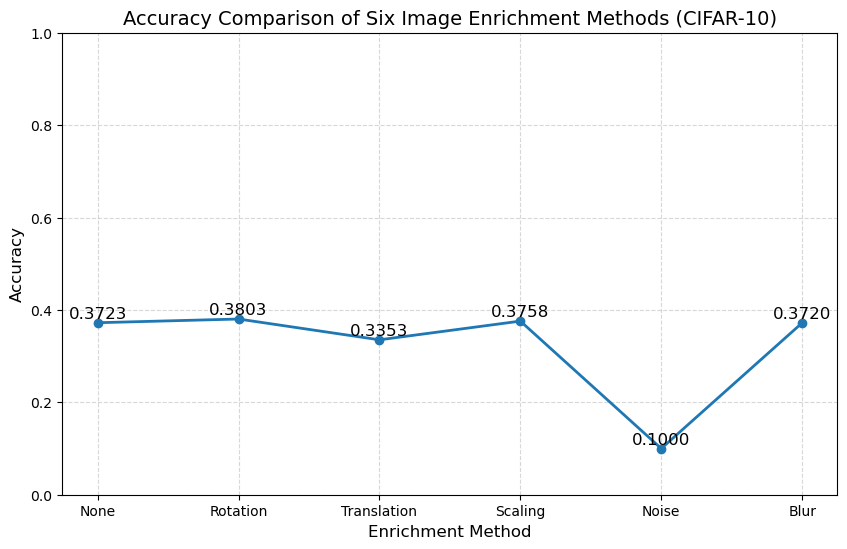

In [17]:
import matplotlib.pyplot as plt

methods = list(results.keys())
acc_values = list(results.values())

plt.figure(figsize=(10,6))
plt.plot(methods, acc_values, marker='o', linewidth=2)

plt.title("Accuracy Comparison of Six Image Enrichment Methods (CIFAR-10)", fontsize=14)
plt.xlabel("Enrichment Method", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.ylim(0, 1)

for i, acc in enumerate(acc_values):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center', fontsize=12)

plt.show()


- The result of line chart indicates that the image enrichment method with the worst effect is the Noise, while the best one is the Rotation.
- In addition, the Scaler and Blur have similar performances.
- Overall, the performance for CIFAR-10 with image data is worse than that of MNIST, as the accuracies of the model after enrichment is significantly lower than that in MNIST.